# 1. MC 이론가 재산출 (torch 엔진) → 학습데이터 완성

`0_data` 가 만든 base(`data/els3_dataset.parquet`, branch·계약·fair)에 **MC 이론가 `mc`** 와 그 입력
(`mc_vol1/2/3`, `mc_rho12/13/23`, `mc_r_krw`, `mc_k`) + 인과적 `recent_margin` + provenance(`mc_engine`/`mc_seed`)
를 추가해 학습데이터를 완성하고, 학습 CSV 2종(`ml`/`deeponet`)을 생성한다.

**엔진**: `module.mc_engine` (torch, CUDA 기본 · CPU 폴백). 일별 GBM + 촐레스키(180일 역사 상관) + 180일 역사 변동성
+ KRW Nelson-Siegel 할인 + q=0 + 일별 KI, **40,000 경로**. 페이오프 규칙은 조기상환(**회차별 지급률**) >
**리자드**(FROM_ISU no-touch, 축소 지급률) > 만기 낙인 판정이고, **노낙인은 `B=1.0`** 으로 always-KI 처리한다.

> **대량 실행**: 약 58,790개 × 40k 경로. GPU 상품당 약 29ms → **전량 30분**. 청크마다 캐시를 남겨 중단해도 이어서 재개된다.
> 아래 셀은 `mc` 가 이미 있으면 생략, 캐시 샤드만 있으면 combine(수 초), 둘 다 없으면 **자동으로 GPU 재산출**을 돌린다.

**캘리브레이션 없음(정본)**: 역사변동성은 내재변동성보다 낮아 MC가 공정가치를 상회한다. 그 편향은 하이브리드의
인과적 `recent_margin` + stage-2 잔차가 흡수한다. (`data/cache/calib_kmap.json` 이 없으면 `k=1`.)

> numpy `module.mc` 는 레거시 레퍼런스로 남아 있고 재산출에는 쓰지 않는다 —
> 두 엔진의 일치는 `python tests/verify_engine_agreement.py` 로 확인한다(200상품, MAE 8.4원).

In [1]:
import json, bisect
import numpy as np, pandas as pd
from util import file_manager as fm
from module import data, mc as MC

kmap = MC.load_kmap()
print("MC 엔진 | NPATH", MC.NPATH)
print("캘리브레이션 kmap:", kmap if kmap else "(없음 → 미보정 MC)")

MC 엔진 | NPATH 40000
캘리브레이션 kmap: (없음 → 미보정 MC)


In [ ]:
# 소량 동작 확인 (base 앞 2개 상품) — 재산출과 같은 torch 엔진
from module.mc_engine import price_one_t, DEFAULT_DEV

mk = MC.load_market()
_df = pd.read_parquet(fm.source()).sort_values("isu_ord").reset_index(drop=True)
print("engine device:", DEFAULT_DEV)
for _i, rw in _df.head(2).iterrows():
    _n = int(rw["nobs"])
    r = price_one_t(mk, kmap, rw["item"], int(rw["isu_ord"]), float(rw["B"]), float(rw["coupon"]),
                    float(rw["tenor"]), float(rw["sig_eff"]), seed=int(_i),
                    strikes=[float(rw[f"strk_{q}"]) for q in range(_n)],
                    pmts=[float(rw[f"pmt_{q}"]) for q in range(_n)],
                    lz_barr=[float(rw[f"lz_barr_{q}"]) for q in range(_n)],
                    lz_pmt=[float(rw[f"lz_pmt_{q}"]) for q in range(_n)])
    print(f"{rw['item']} [{rw['opt_type']}/{'KI' if rw['ki_yn'] else 'no-KI'}] "
          f"-> mc {r[0]:.4f} | k {r[8]:.3f} | fair {rw['fair']:.4f}")

## 전체 재산출 (GPU 순차 청크) → els3_dataset 갱신

재산출 엔진은 `module.mc_engine`(torch CUDA)이다. `module.mc_shards.recompute_gpu(N)` 이 청크를 순차 처리하며
청크마다 `data/cache/mccal_shard_<k>.json` 을 쓰므로 중단해도 이어서 재개된다.
완료 후 `combine` 이 `mc`·MC입력·`recent_margin`(구조별)·`mc_engine`·`mc_seed` 를 parquet 에 기록한다.

아래 셀이 상태를 보고 알아서 처리한다 — **노트북만 순서대로 돌려도 된다**:

| 상태 | 동작 |
|---|---|
| `mc` 이미 있음 | 생략 |
| `mc` 없음 + 캐시 샤드 있음 | `combine` (수 초) |
| 둘 다 없음 | `recompute_gpu` 로 전량 재산출(약 30분) 후 `combine` |

터미널에서 돌리려면(진행상황을 별도 창에서 보고 싶을 때):
```bash
python -m module.mc_shards gpu 28
python -m module.mc_shards combine 28
```

In [ ]:
FORCE = False   # True 로 두면 캐시가 있어도 지우고 전량 재산출 (약 30분)
NCHUNK = 28     # GPU 순차 청크 수 (재개 단위)

from module import mc_shards
df = pd.read_parquet(fm.source()).sort_values("isu_ord").reset_index(drop=True)
has_mc = "mc" in df.columns                            # ① mc 컬럼 존재 여부
shards = sorted(fm.CACHE.glob("mccal_shard_*.json"))   # ② 캐시된 MC 샤드 JSON 존재 여부
print(f"mc 컬럼: {'있음' if has_mc else '없음'} | 캐시 샤드 JSON: {len(shards)}개 | FORCE={FORCE}")

if FORCE:
    for p in shards:
        p.unlink()
    print(f"→ FORCE: 캐시 {len(shards)}개 삭제 후 전량 재산출")
    mc_shards.recompute_gpu(NCHUNK, kmap=kmap)
    mc_shards.combine(NCHUNK)
elif has_mc:                                           # 이미 mc 있음 → 재계산 생략
    print("→ 재계산 생략 (기존 mc 사용)")
elif shards:                                           # 캐시 샤드 있음 → combine (수 초)
    print(f"→ 캐시된 샤드 {len(shards)}개 combine")
    mc_shards.combine()                                # N 자동감지
else:                                                  # 둘 다 없음 → GPU 전량 재산출
    print("→ mc·캐시 모두 없음: GPU 전량 재산출 (약 30분, 청크마다 캐시 저장 → 중단시 재개 가능)")
    mc_shards.recompute_gpu(NCHUNK, kmap=kmap)
    mc_shards.combine(NCHUNK)

df = pd.read_parquet(fm.source()).sort_values("isu_ord").reset_index(drop=True)
print(f"rows {len(df)} | engine {df.mc_engine.iloc[0]} | mc {df.mc.mean():.4f} ({df.mc_krw.mean():,.0f}원) | "
      f"fair {df.fair.mean():.4f} ({df.fair_krw.mean():,.0f}원) | "
      f"fair-mc {df.fair_minus_mc_krw.mean():+,.0f}원 | k mean {df.mc_k.mean():.3f} | nan {int(df.mc.isna().sum())}")

## 학습 CSV 2종 생성

완성된 `els3_dataset.parquet`(branch + `mc` + `recent_margin`)에서 `data/ml.csv`·`data/deeponet.csv` 를 생성한다. 이후 `2_run` 이 이 CSV 로 학습한다.

In [4]:
info = data.build_datasets()
print("rows:", {k: info[k] for k in ("ml", "deeponet")})
for name in ("ml", "deeponet"):
    c = pd.read_csv(fm.dataset(name), encoding=data.CSV_ENC, nrows=1)
    print(f"  {name}.csv cols {c.shape[1]}")

rows: {'ml': 58790, 'deeponet': 58790}
  ml.csv cols 67
  deeponet.csv cols 74


## MC 이론가 vs 공정가치 — 히스토그램 (발행가 10,000원 기준)

`(공정가치 − MC)` 원 단위 분포. 무보정 MC라 평균이 음수(≈ −507원)로 **MC가 공정가치를 상회(과대평가)** 하는 역사변동성 편향을 보인다. 이 잔차(마진·방법론 gap)가 하이브리드 ML의 학습 대상이다.

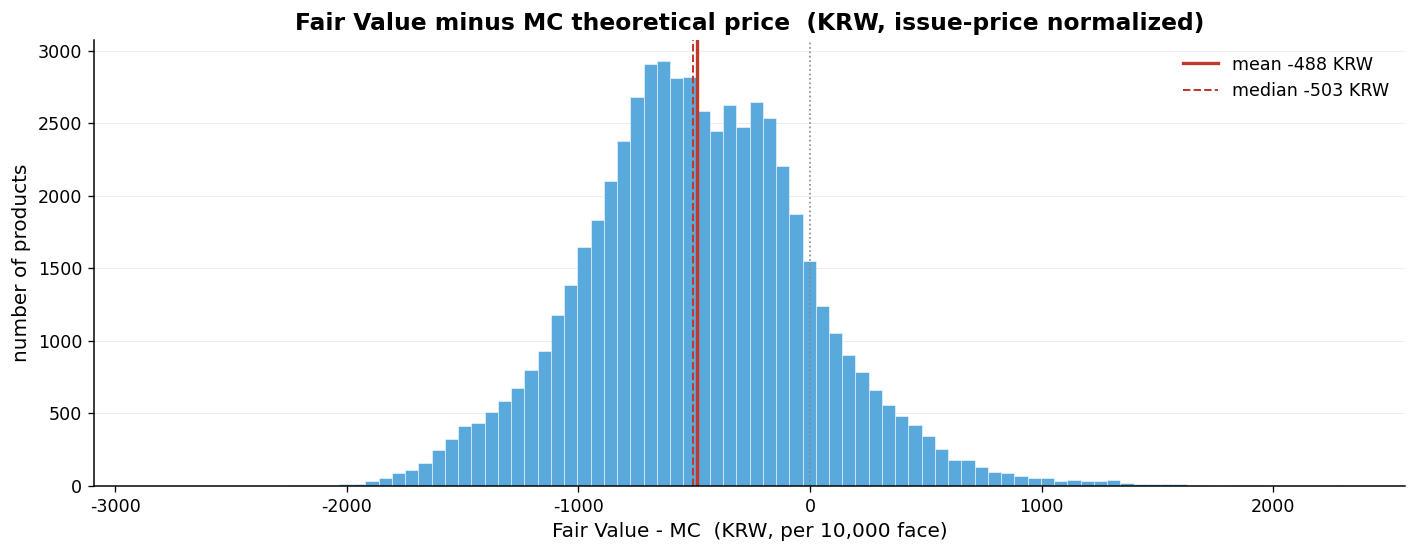

MC 평균 9,780원 | 공정가치 평균 9,293원
(공정가치 − MC) 평균 -488 | 중앙값 -503 | 표준편차 492


In [5]:
from util import plot as _plot   # 학술 rcParams (상/우 spine 제거 등)
import matplotlib.pyplot as plt

diff = df["fair_minus_mc_krw"].dropna()
fig, ax = plt.subplots(figsize=(12, 4.8))   # PPT 콘텐츠 밴드에 맞춤
ax.hist(diff, bins=90, color="#5aa9dd", edgecolor="white", linewidth=.3)
ax.axvline(diff.mean(), color="#c0392b", lw=2, label=f"mean {diff.mean():,.0f} KRW")
ax.axvline(diff.median(), color="#c0392b", lw=1.2, ls="--", label=f"median {diff.median():,.0f} KRW")
ax.axvline(0, color="#888", lw=1, ls=":")
ax.set_xlabel("Fair Value - MC  (KRW, per 10,000 face)")
ax.set_ylabel("number of products")
ax.set_title("Fair Value minus MC theoretical price  (KRW, issue-price normalized)")
ax.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)
ax.legend(); fig.tight_layout()
fig.savefig(fm.image("fair_minus_mc_hist"), dpi=400, bbox_inches="tight", transparent=True); plt.show()
print(f"MC 평균 {df['mc_krw'].mean():,.0f}원 | 공정가치 평균 {df['fair_krw'].mean():,.0f}원")
print(f"(공정가치 − MC) 평균 {diff.mean():,.0f} | 중앙값 {diff.median():,.0f} | 표준편차 {diff.std():,.0f}")

## 가격 구간별 (공정가치 − MC) 오차

공정가치 6분위 구간별 `(공정가치 − MC)` 오차와 MAPE. 무보정 MC는 **저가(위험) 구간을 크게 과대평가**(오차 음수·MAPE↑)하고 고가(안전) 구간으로 갈수록 오차가 작아진다 — 역사변동성이 하방 스큐를 못 담는 구조적 편향. (`mc_k`는 무보정이라 전 구간 1.0.)

                   n  fair_mean  mc_mean  err_mean_KRW  err_median_KRW  MAPE_pct  k_mean
price_seg                                                                               
(0.699, 0.884]  9799       0.85     0.95       -913.37        -1054.71     11.61     1.0
(0.884, 0.912]  9798       0.90     0.97       -700.06         -833.04      8.55     1.0
(0.912, 0.933]  9799       0.92     0.98       -594.60         -703.15      6.94     1.0
(0.933, 0.953]  9797       0.94     0.99       -435.88         -543.14      5.36     1.0
(0.953, 0.976]  9800       0.96     0.99       -268.47         -334.08      3.55     1.0
(0.976, 1.05]   9797       0.99     0.99        -13.38          -79.29      2.12     1.0


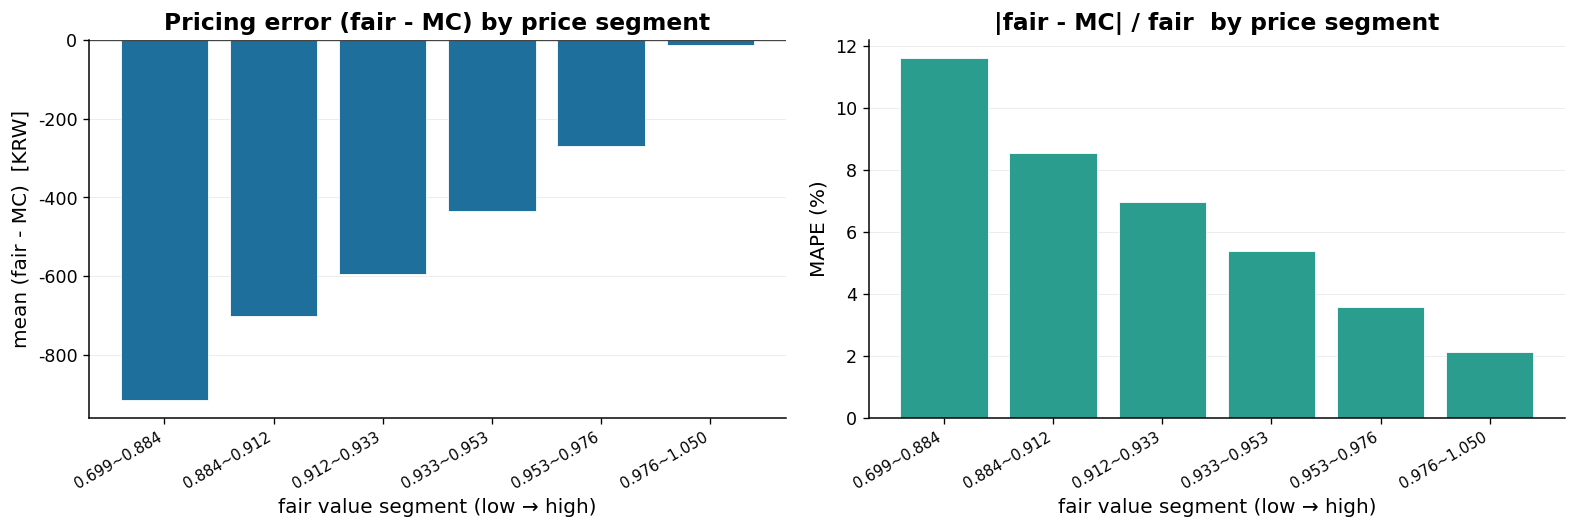

saved -> mae_err_by_price_seg.png


In [6]:
from util import plot as _plot   # 학술 rcParams
FACE = 10000
d2 = df.dropna(subset=["fair", "mc"]).copy()
d2["err_krw"] = (d2["fair"] - d2["mc"]) * FACE
d2["ape_pct"] = (d2["fair"] - d2["mc"]).abs() / d2["fair"].abs() * 100
d2["price_seg"] = pd.qcut(d2["fair"], 6)
g = d2.groupby("price_seg", observed=True).agg(
    n=("err_krw", "size"), fair_mean=("fair", "mean"), mc_mean=("mc", "mean"),
    err_mean_KRW=("err_krw", "mean"), err_median_KRW=("err_krw", "median"),
    MAPE_pct=("ape_pct", "mean"), k_mean=("mc_k", "mean"))
print(g.round(2).to_string())

xs = np.arange(len(g)); xl = [f"{iv.left:.3f}~{iv.right:.3f}" for iv in g.index]
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.6))   # PPT 콘텐츠 밴드
ax[0].bar(xs, g["err_mean_KRW"].values, color=np.where(g["err_mean_KRW"].values > 0, "#e07a5f", "#1f6f9c"),
          edgecolor="white", linewidth=0.5)
ax[0].axhline(0, color="#444", lw=.8)
ax[0].set_xticks(xs); ax[0].set_xticklabels(xl, rotation=30, fontsize=9, ha="right")
ax[0].set_ylabel("mean (fair - MC)  [KRW]"); ax[0].set_xlabel("fair value segment (low → high)")
ax[0].set_title("Pricing error (fair - MC) by price segment")
ax[0].grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)
ax[1].bar(xs, g["MAPE_pct"].values, color="#2a9d8f", edgecolor="white", linewidth=0.5)
ax[1].set_xticks(xs); ax[1].set_xticklabels(xl, rotation=30, fontsize=9, ha="right")
ax[1].set_ylabel("MAPE (%)"); ax[1].set_xlabel("fair value segment (low → high)")
ax[1].set_title("|fair - MC| / fair  by price segment")
ax[1].grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)
fig.tight_layout()
fig.savefig(fm.image("mae_err_by_price_seg"), dpi=400, bbox_inches="tight", transparent=True); plt.show()
print("saved ->", fm.image("mae_err_by_price_seg").name)

## 4구조 유니버스 리포트

STEP/LIZARD × 낙인/노낙인 네 구조가 모두 들어왔는지, 스케줄·엔진 provenance 가 기록됐는지 확인한다.

In [7]:
# 구조별 유니버스 리포트 (4구조 확장 검증)
rep = df.groupby(["opt_type", "ki_yn"]).agg(
    n=("item", "size"), mc=("mc", "median"), fair=("fair", "median"),
    coupon=("coupon", "median"), Klast=("K", "median"), B=("B", "median")).round(4)
rep["fair_minus_mc"] = (rep["fair"] - rep["mc"]).round(4)
print(rep.to_string())
lzcols = [f"lz_barr_{j}" for j in range(12)]
print(f"\n총 {len(df):,}건 | 리자드 보유 {int(df[lzcols].notna().any(axis=1).sum()):,}건 "
      f"| 지급률 선형 대체(raw 비단조) {int(df['pmt_linear'].sum()):,}건 | MC 엔진 {df['mc_engine'].iloc[0]}")
print(f"기초자산 조합 {df['udl_key'].nunique()}종 | 최빈 {df['udl_key'].value_counts().iloc[0] / len(df):.1%}")
print("\n노낙인(B=1.0)은 만기 행사가가 낮고(0.65 vs 0.75) 쿠폰도 낮아, 낙인형과의 mc 대소는"
      "\n구조 자체가 아니라 계약 조건 차이로 결정된다. 규칙 자체의 방향성(리자드 +, 낙인보호 +)은"
      "\ntests/test_mc_engine.py 의 결정론 테스트와 실물 on/off 대조로 확인했다.")

                    n      mc    fair  coupon  Klast    B  fair_minus_mc
opt_type ki_yn                                                          
LIZARD   0       9880  0.9995  0.9326  0.0411   0.65  1.0        -0.0669
         1       1781  0.9942  0.9207  0.0550   0.75  0.5        -0.0735
STEP     0      24048  0.9887  0.9313  0.0540   0.65  1.0        -0.0574
         1      23081  0.9927  0.9358  0.0620   0.75  0.5        -0.0569

총 58,790건 | 리자드 보유 11,661건 | 지급률 선형 대체(raw 비단조) 395건 | MC 엔진 cuda
기초자산 조합 239종 | 최빈 24.2%

노낙인(B=1.0)은 만기 행사가가 낮고(0.65 vs 0.75) 쿠폰도 낮아, 낙인형과의 mc 대소는
구조 자체가 아니라 계약 조건 차이로 결정된다. 규칙 자체의 방향성(리자드 +, 낙인보호 +)은
tests/test_mc_engine.py 의 결정론 테스트와 실물 on/off 대조로 확인했다.
